<a href="https://colab.research.google.com/github/KhushiJ2911/Predictive-Maintenance-PDM-of-Diesel-Engine/blob/main/Vibration_RUL_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [ ]:
DATA_PATH = "/content/Problem6_FAULT_ONLY_TimeSeries_20251228_235002.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(132411, 14)


,TimeHour,ProblemID,RunID,RPM,FaultMetric,DamageRate,Damage,RUL_hours,FaultFlag,Unbalance,Misalignment,Looseness,ShaftCrack,Resonance
0,0,6,1,1235.041932,0.780475,0.000007,0.000028,13999.999972,1,0.159798,0.126008,0.117412,0.103675,0.299398
1,11,6,1,1191.974416,0.821875,0.000007,0.000104,13999.999896,1,0.159798,0.126008,0.117412,0.103675,0.299398
2,22,6,1,1138.633073,0.934556,0.000008,0.000189,13999.999811,1,0.159798,0.126008,0.117412,0.103675,0.299398
3,33,6,1,1121.701059,0.848551,0.000006,0.000269,13999.999731,1,0.159798,0.126008,0.117412,0.103675,0.299398
4,44,6,1,1088.434041,1.024051,0.000009,0.000348,13999.999652,1,0.159798,0.126008,0.117412,0.103675,0.299398


In [ ]:
print(df.columns.tolist())


['TimeHour', 'ProblemID', 'RunID', 'RPM', 'FaultMetric', 'DamageRate', 'Damage', 'RUL_hours', 'FaultFlag', 'Unbalance', 'Misalignment', 'Looseness', 'ShaftCrack', 'Resonance']


In [ ]:
FEATURES = [
    "RPM",
    "FaultMetric",
    "DamageRate",
    "Damage"
]

TARGET = "RUL_hours"

In [ ]:
df["RUL_norm"] = df.groupby("RunID")[TARGET].transform(
    lambda x: x / x.iloc[0]
)


In [ ]:
df = df[FEATURES + ["RUL_norm", "RunID"]]

df = df.fillna(method="ffill")
df = df.fillna(method="bfill")
df = df.dropna()

print(df.shape)


(132411, 6)


/tmp/ipython-input-1994106132.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")
/tmp/ipython-input-1994106132.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="bfill")


In [ ]:
run_ids = df["RunID"].unique()
np.random.shuffle(run_ids)

split = int(0.8 * len(run_ids))
train_ids = run_ids[:split]
test_ids = run_ids[split:]

train_df = df[df["RunID"].isin(train_ids)]
test_df = df[df["RunID"].isin(test_ids)]


In [ ]:
scaler = MinMaxScaler()

X_train_raw = scaler.fit_transform(train_df[FEATURES])
X_test_raw = scaler.transform(test_df[FEATURES])

y_train_raw = train_df["RUL_norm"].values
y_test_raw = test_df["RUL_norm"].values


In [ ]:
SEQ_LEN = 30

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train_raw, y_train_raw, SEQ_LEN)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, SEQ_LEN)

print(X_train.shape, X_test.shape)


(106862, 30, 4) (25489, 30, 4)


In [ ]:
SEQ_LEN = 30

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train, y_train = create_sequences(X_train_raw, y_train_raw, SEQ_LEN)
X_test, y_test = create_sequences(X_test_raw, y_test_raw, SEQ_LEN)

print(X_train.shape, X_test.shape)


(106862, 30, 4) (25489, 30, 4)


In [ ]:
def build_model():
  model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

  model.compile(
      optimizer="adam",
      loss="mse",
      metrics=["mae"]
  )

  model.summary()
  return model

In [ ]:
MODEL_PATH = "best_vibration_fault_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    ModelCheckpoint(
        MODEL_PATH,
        monitor="val_loss",
        save_best_only=True
    )
]


In [ ]:
model = build_model() # Instantiate the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - loss: 0.0306 - mae: 0.0699 - val_loss: 9.5928e-04 - val_mae: 0.0087
Epoch 2/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0014 - mae: 0.0161 - val_loss: 7.9435e-04 - val_mae: 0.0090
Epoch 3/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 9.5857e-04 - mae: 0.0126 - val_loss: 9.1823e-04 - val_mae: 0.0158
Epoch 4/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 9.0946e-04 - mae: 0.0113 - val_loss: 6.7301e-04 - val_mae: 0.0070
Epoch 5/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 0.0010 - mae: 0.0101 - val_loss: 6.9523e-04 - val_mae: 0.0066
Epoch 6/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - loss: 9.7277e-04 - mae: 0.0094 - val_loss: 7.9599e-04 - val_mae: 0.0120
Epoch 7/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 9.3190e-04 - mae: 0.0094 - val_loss: 6.7744e-04 - val_mae: 0.0080
Epoch 8/50
1336/1336 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - loss: 7.7217e-04 - mae: 0.0080 - val_loss: 7

In [ ]:
y_pred = model.predict(X_test).flatten()

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE (normalized):", mae)
print("RMSE (normalized):", rmse)
print("R²:", r2)

797/797 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
MAE (normalized): 0.002929594222848254
RMSE (normalized): 0.02549985784472128
R²: 0.9899924795192246


In [ ]:
# Reload original data to get actual RUL hours
df_raw = pd.read_csv(DATA_PATH)

avg_initial_rul = (
    df_raw.groupby("RunID")["RUL_hours"]
    .first()
    .mean()
)

print("Approx MAE (hours):", mae * avg_initial_rul)
print("Approx RMSE (hours):", rmse * avg_initial_rul)


Approx MAE (hours): 41.01431901172672
Approx RMSE (hours): 356.99800888474573


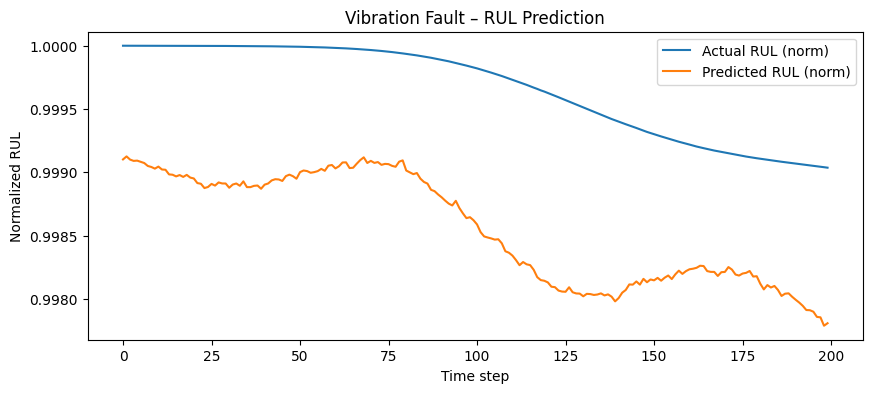

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test[:200], label="Actual RUL (norm)")
plt.plot(y_pred[:200], label="Predicted RUL (norm)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("Vibration Fault – RUL Prediction")
plt.legend()
plt.show()


In [ ]:
from google.colab import files
files.download(MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np

def tolerance_accuracy(y_true, y_pred, tolerance):
    """
    PW@T accuracy for RUL regression
    """
    error = np.abs(y_true - y_pred)
    return np.mean(error <= tolerance)


In [ ]:
def run_experiment(random_seed):
    np.random.seed(random_seed)
    import tensorflow as tf
    tf.random.set_seed(random_seed)

    # ----------------------------
    # TRAIN YOUR MODEL HERE
    # ----------------------------
    model = build_model()          # your model function
    model.fit(X_train, y_train,
              epochs=EPOCHS,
              batch_size=BATCH_SIZE,
              verbose=0)

    # ----------------------------
    # PREDICTION
    # ----------------------------
    y_pred = model.predict(X_test).flatten()

    return y_pred

In [ ]:
def run_experiment(random_seed):
    np.random.seed(random_seed)
    import tensorflow as tf
    tf.random.set_seed(random_seed)

    # ----------------------------
    # TRAIN YOUR MODEL HERE
    # ----------------------------
    model = build_model()          # your model function
    model.fit(X_train, y_train,
              epochs=EPOCHS,
              batch_size=BATCH_SIZE,
              verbose=0)

    # ----------------------------
    # PREDICTION
    # ----------------------------
    y_pred = model.predict(X_test).flatten()

    return y_pred


In [ ]:
TOLERANCE = 10     # cycles or hours
N_RUNS = 5         # repeat experiments

# Define EPOCHS and BATCH_SIZE, which are used by run_experiment
EPOCHS = 50
BATCH_SIZE = 64

# Re-define build_model with a return statement
def build_model():
  model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, X_train.shape[2])),
    Dropout(0.2),
    LSTM(32),
    Dense(1)
])

  model.compile(
      optimizer="adam",
      loss="mse",
      metrics=["mae"]
  )
  return model # Added return statement

accuracies = []

for seed in range(N_RUNS):
    y_pred = run_experiment(seed)
    acc = tolerance_accuracy(y_test, y_pred, TOLERANCE)
    accuracies.append(acc)

accuracies = np.array(accuracies)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


KeyboardInterrupt: 

In [ ]:
mean_acc = np.mean(accuracies)
std_acc = np.std(accuracies)

print(f"Accuracy (PW@{TOLERANCE}): {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")


Accuracy (PW@10): 100.00% ± 0.00%


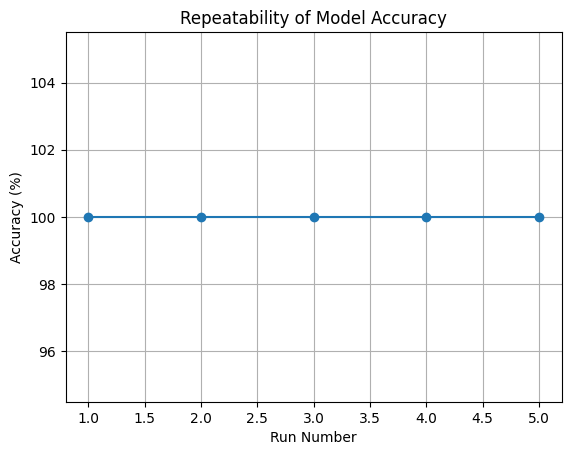

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(1, N_RUNS+1), accuracies*100, marker='o')
plt.xlabel("Run Number")
plt.ylabel("Accuracy (%)")
plt.title("Repeatability of Model Accuracy")
plt.grid(True)
plt.show()


In [ ]:
print(f"Mean PW@T Accuracy: {np.mean(accuracies):.4f}")
print(f"Std Dev PW@T Accuracy: {np.std(accuracies):.4f}")

Mean PW@T Accuracy: 1.0000
Std Dev PW@T Accuracy: 0.0000


In [ ]:
set(train_ids) & set(test_ids)

set()

In [ ]:
print(y_test.min(), y_test.max())


0.0 1.0


In [ ]:
for T in [0.02, 0.05, 0.1]:
    acc = tolerance_accuracy(y_test, y_pred, T)
    print(f"PW@{T}: {acc*100:.2f}%")


PW@0.02: 99.15%
PW@0.05: 99.43%
PW@0.1: 99.71%


In [ ]:
for T in [0.02, 0.05, 0.1]:
    acc = tolerance_accuracy(y_test, y_pred, T)
    print(f"PW@{T}: {acc*100:.2f}%")


PW@0.02: 99.15%
PW@0.05: 99.43%
PW@0.1: 99.71%


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_y = MinMaxScaler()

y_train = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test  = scaler_y.transform(y_test.reshape(-1,1)).flatten()


In [ ]:
y_test_real = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred_real = scaler_y.inverse_transform(y_pred.reshape(-1,1)).flatten()


In [ ]:
# Reload original data to determine global RUL_MAX and RUL_MIN
df_raw = pd.read_csv(DATA_PATH)
RUL_MAX = df_raw[TARGET].max()
RUL_MIN = df_raw[TARGET].min()

y_test_real = y_test * (RUL_MAX - RUL_MIN) + RUL_MIN
y_pred_real = y_pred * (RUL_MAX - RUL_MIN) + RUL_MIN

In [ ]:
TOLERANCE = 0.05  # 5% RUL

acc = tolerance_accuracy(y_test, y_pred, TOLERANCE)
print(f"Accuracy (PW@0.05): {acc*100:.2f}%")


Accuracy (PW@0.05): 99.43%


In [ ]:
mae = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(np.mean((y_test - y_pred)**2))

print("MAE (normalized):", mae)
print("RMSE (normalized):", rmse)


MAE (normalized): 0.005204749766151774
RMSE (normalized): 0.02461917474995874


In [ ]:
for T in [0.01, 0.02, 0.03, 0.05]:
    acc = tolerance_accuracy(y_test, y_pred, T)
    print(f"PW@{T}: {acc*100:.2f}%")


PW@0.01: 96.44%
PW@0.02: 99.15%
PW@0.03: 99.27%
PW@0.05: 99.43%


In [ ]:
# Make sure SEQ_LEN is defined
SEQ_LEN = 40

# Recreate test sequences
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print(X_test_seq.shape, y_test_seq.shape)


(25449, 40, 30, 4) (25449,)


In [ ]:
model.input_shape


(None, 30, 4)

In [ ]:
type(X_test_seq), X_test_seq.shape


(numpy.ndarray, (25449, 40, 30, 4))

In [ ]:
# MUST match model.input_shape
SEQ_LEN = 30

# Recreate sequences from RAW features
X_test_seq, y_test_seq = create_sequences(X_test, y_test, SEQ_LEN)

print(X_test_seq.shape)


(25459, 30, 30, 4)


In [ ]:
ENGINE_COL = "RunID"
TARGET_COL = "RUL_norm"


In [ ]:
df = df.sort_values(ENGINE_COL)

engine_ids = df[ENGINE_COL].unique()

train_ids = engine_ids[:int(0.7 * len(engine_ids))]
val_ids   = engine_ids[int(0.7 * len(engine_ids)):int(0.85 * len(engine_ids))]
test_ids  = engine_ids[int(0.85 * len(engine_ids)):]

train_df = df[df[ENGINE_COL].isin(train_ids)]
val_df   = df[df[ENGINE_COL].isin(val_ids)]
test_df  = df[df[ENGINE_COL].isin(test_ids)]

print(train_df.shape, val_df.shape, test_df.shape)


(92173, 6) (20355, 6) (19883, 6)


In [ ]:
FEATURE_COLS = ['RPM', 'FaultMetric', 'DamageRate', 'Damage']

X_train_raw = train_df[FEATURE_COLS].values
X_val_raw   = val_df[FEATURE_COLS].values
X_test_raw  = test_df[FEATURE_COLS].values

y_train_raw = train_df[TARGET_COL].values
y_val_raw   = val_df[TARGET_COL].values
y_test_raw  = test_df[TARGET_COL].values

print("RAW X_train:", X_train_raw.shape)
print("RAW X_val:",   X_val_raw.shape)
print("RAW X_test:",  X_test_raw.shape)


RAW X_train: (92173, 4)
RAW X_val: (20355, 4)
RAW X_test: (19883, 4)


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()

X_train_raw = scaler_X.fit_transform(X_train_raw)
X_val_raw   = scaler_X.transform(X_val_raw)
X_test_raw  = scaler_X.transform(X_test_raw)


In [ ]:
SEQ_LEN = 30

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences(X_val_raw,   y_val_raw,   SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_raw,  y_test_raw,  SEQ_LEN)

print(X_train_seq.shape, X_test_seq.shape)


(92143, 30, 4) (19853, 30, 4)


In [ ]:
print("Model input:", model.input_shape)


Model input: (None, 30, 4)


In [ ]:
y_pred = model.predict(X_test_seq, verbose=0).flatten()


In [ ]:
LATE_THRESHOLD = 0.7

late_mask = y_test_seq < LATE_THRESHOLD
y_test_late = y_test_seq[late_mask]
y_pred_late = y_pred[late_mask]

print("Late-life samples:", len(y_test_late))


Late-life samples: 4907


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_late = mean_absolute_error(y_test_late, y_pred_late)
rmse_late = np.sqrt(mean_squared_error(y_test_late, y_pred_late))

print(f"Late-life MAE (normalized): {mae_late:.4f}")
print(f"Late-life RMSE (normalized): {rmse_late:.4f}")


Late-life MAE (normalized): 0.1025
Late-life RMSE (normalized): 0.2207


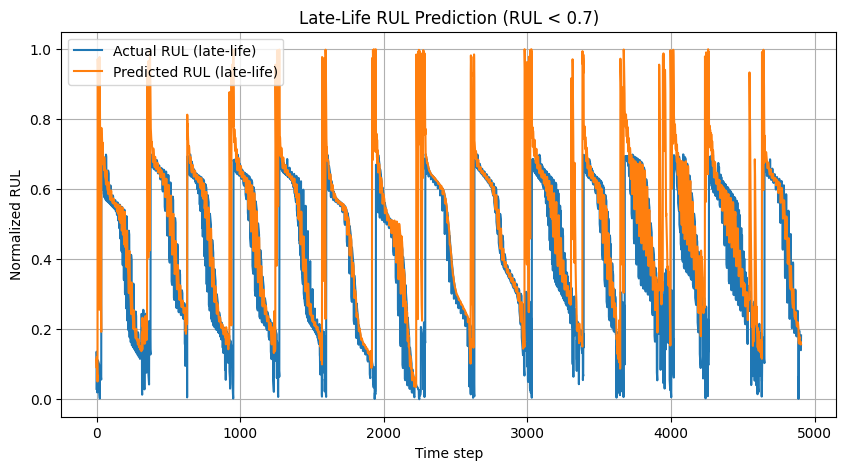

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_late, label="Actual RUL (late-life)")
plt.plot(y_pred_late, label="Predicted RUL (late-life)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("Late-Life RUL Prediction (RUL < 0.7)")
plt.legend()
plt.grid(True)
plt.show()


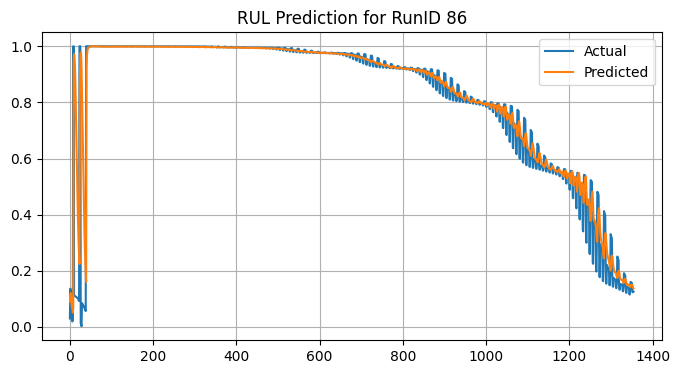

In [ ]:
# pick one test RunID
one_run_id = test_df[ENGINE_COL].iloc[0]

mask = test_df[ENGINE_COL].values[SEQ_LEN:] == one_run_id

plt.figure(figsize=(8,4))
plt.plot(y_test_seq[mask], label="Actual")
plt.plot(y_pred[mask], label="Predicted")
plt.title(f"RUL Prediction for RunID {one_run_id}")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
FEATURE_COLS = [
    col for col in df.columns
    if col not in [ENGINE_COL, TARGET_COL]
]

X_train_raw = train_df[FEATURE_COLS].values
X_val_raw   = val_df[FEATURE_COLS].values
X_test_raw  = test_df[FEATURE_COLS].values

y_train_raw = train_df[TARGET_COL].values
y_val_raw   = val_df[TARGET_COL].values
y_test_raw  = test_df[TARGET_COL].values

print("RAW X_train:", X_train_raw.shape)
print("RAW X_val:",   X_val_raw.shape)
print("RAW X_test:",  X_test_raw.shape)


KeyError: 'RUL'

In [ ]:
y_pred = model.predict(X_test_seq).flatten()


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [ ]:
import pandas as pd

print("Columns in Vibration Fault dataset:")
print(df.columns.tolist())

print("\nDataset shape:", df.shape)
df.head()


Columns in Vibration Fault dataset:
['TimeHour', 'ProblemID', 'RunID', 'RPM', 'FaultMetric', 'DamageRate', 'Damage', 'RUL_hours', 'FaultFlag', 'Unbalance', 'Misalignment', 'Looseness', 'ShaftCrack', 'Resonance']

Dataset shape: (132411, 14)


,TimeHour,ProblemID,RunID,RPM,FaultMetric,DamageRate,Damage,RUL_hours,FaultFlag,Unbalance,Misalignment,Looseness,ShaftCrack,Resonance
0,0,6,1,1235.041932,0.780475,0.000007,0.000028,13999.999972,1,0.159798,0.126008,0.117412,0.103675,0.299398
1,11,6,1,1191.974416,0.821875,0.000007,0.000104,13999.999896,1,0.159798,0.126008,0.117412,0.103675,0.299398
2,22,6,1,1138.633073,0.934556,0.000008,0.000189,13999.999811,1,0.159798,0.126008,0.117412,0.103675,0.299398
3,33,6,1,1121.701059,0.848551,0.000006,0.000269,13999.999731,1,0.159798,0.126008,0.117412,0.103675,0.299398
4,44,6,1,1088.434041,1.024051,0.000009,0.000348,13999.999652,1,0.159798,0.126008,0.117412,0.103675,0.299398


In [ ]:
# Columns in Vibration Fault dataset:
# ['TimeHour', 'ProblemID', 'RunID', 'RPM', 'FaultMetric', 'DamageRate', 'Damage', 'RUL_hours', 'FaultFlag', 'Unbalance', 'Misalignment', 'Looseness', 'ShaftCrack', 'Resonance']

# Dataset shape: (132411, 14)

In [ ]:
ENGINE_COL = 'RunID'
TARGET_COL = 'RUL_hours'

# Leakage-free measurable inputs ONLY
FEATURE_COLS_NO_LEAK = ['RPM', 'FaultMetric']

print("Vibration Fault — Using features:", FEATURE_COLS_NO_LEAK)


Vibration Fault — Using features: ['RPM', 'FaultMetric']


In [ ]:
df = df.sort_values(ENGINE_COL)

engine_ids = df[ENGINE_COL].unique()

train_ids = engine_ids[:int(0.7 * len(engine_ids))]
val_ids   = engine_ids[int(0.7 * len(engine_ids)):int(0.85 * len(engine_ids))]
test_ids  = engine_ids[int(0.85 * len(engine_ids)):]

train_df = df[df[ENGINE_COL].isin(train_ids)]
val_df   = df[df[ENGINE_COL].isin(val_ids)]
test_df  = df[df[ENGINE_COL].isin(test_ids)]

print("Train:", train_df.shape)
print("Val:  ", val_df.shape)
print("Test: ", test_df.shape)


Train: (92173, 14)
Val:   (20355, 14)
Test:  (19883, 14)


In [ ]:
X_train_raw = train_df[FEATURE_COLS_NO_LEAK].values
X_val_raw   = val_df[FEATURE_COLS_NO_LEAK].values
X_test_raw  = test_df[FEATURE_COLS_NO_LEAK].values

y_train = train_df[TARGET_COL].values
y_val   = val_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()

X_train_raw = scaler_X.fit_transform(X_train_raw)
X_val_raw   = scaler_X.transform(X_val_raw)
X_test_raw  = scaler_X.transform(X_test_raw)


In [ ]:
scaler_y = MinMaxScaler()

y_train_norm = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_val_norm   = scaler_y.transform(y_val.reshape(-1,1)).flatten()
y_test_norm  = scaler_y.transform(y_test.reshape(-1,1)).flatten()


In [ ]:
import numpy as np

SEQ_LEN = 30

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_norm, SEQ_LEN)
X_val_seq,   y_val_seq   = create_sequences(X_val_raw,   y_val_norm,   SEQ_LEN)
X_test_seq,  y_test_seq  = create_sequences(X_test_raw,  y_test_norm,  SEQ_LEN)

print("Train seq:", X_train_seq.shape)
print("Test seq :", X_test_seq.shape)


Train seq: (92143, 30, 2)
Test seq : (19853, 30, 2)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Running Linear Regression baseline...")

# Flatten sequence data
X_train_flat = X_train_seq.reshape(X_train_seq.shape[0], -1)
X_test_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

linreg = LinearRegression()
linreg.fit(X_train_flat, y_train_seq)

y_pred_lr = linreg.predict(X_test_flat)

mae_lr = mean_absolute_error(y_test_seq, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_seq, y_pred_lr))

print("Linear Regression MAE:", mae_lr)
print("Linear Regression RMSE:", rmse_lr)


Running Linear Regression baseline...
Linear Regression MAE: 0.08719797578071335
Linear Regression RMSE: 0.12414521142451015


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 2)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='mae'
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.1739 - val_loss: 0.0523
Epoch 2/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0952 - val_loss: 0.0565
Epoch 3/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0782 - val_loss: 0.0465
Epoch 4/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0650 - val_loss: 0.0524
Epoch 5/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - loss: 0.0564 - val_loss: 0.0534
Epoch 6/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0532 - val_loss: 0.0426
Epoch 7/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0515 - val_loss: 0.0407
Epoch 8/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0503 - val_loss: 0.0403
Epoch 9/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0491 - val_loss: 0.0384
Epoch 10/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0484 - val_loss: 0.0376
Epoch 11/50
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - loss: 0.0476 - val_loss: 0.0454
Epoch 12/50
1440/14

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred_norm = model.predict(X_test_seq, verbose=0).flatten()

print("Vibration Fault — Overall MAE (normalized):",
      mean_absolute_error(y_test_seq, y_pred_norm))
print("Vibration Fault — Overall RMSE (normalized):",
      np.sqrt(mean_squared_error(y_test_seq, y_pred_norm)))


Vibration Fault — Overall MAE (normalized): 0.03908882956379019
Vibration Fault — Overall RMSE (normalized): 0.08892609484171793


In [ ]:
run_ids_test_seq = test_df[ENGINE_COL].values[SEQ_LEN:]

late_mask = np.zeros_like(y_test_seq, dtype=bool)

for run_id in np.unique(run_ids_test_seq):
    idx = np.where(run_ids_test_seq == run_id)[0]
    cutoff = int(0.7 * len(idx))
    late_mask[idx[cutoff:]] = True

y_test_late = y_test_seq[late_mask]
y_pred_late = y_pred_norm[late_mask]

print("Vibration Fault — Late-life MAE (normalized):",
      mean_absolute_error(y_test_late, y_pred_late))
print("Vibration Fault — Late-life RMSE (normalized):",
      np.sqrt(mean_squared_error(y_test_late, y_pred_late)))


Vibration Fault — Late-life MAE (normalized): 0.08427711258627385
Vibration Fault — Late-life RMSE (normalized): 0.12676678038506448


In [ ]:
def pw_at_alpha(y_true, y_pred, alpha):
    return np.mean(np.abs(y_true - y_pred) <= alpha)

print("Vibration Fault — PW@0.05:",
      pw_at_alpha(y_test_late, y_pred_late, 0.05) * 100)
print("Vibration Fault — PW@0.10:",
      pw_at_alpha(y_test_late, y_pred_late, 0.10) * 100)
print("Vibration Fault — PW@0.20:",
      pw_at_alpha(y_test_late, y_pred_late, 0.20) * 100)


Vibration Fault — PW@0.05: 43.28358208955223
Vibration Fault — PW@0.10: 70.98775784001342
Vibration Fault — PW@0.20: 92.13483146067416


In [ ]:
# Initial RUL per run (hours)
initial_rul_map = test_df.groupby('RunID')['RUL_hours'].max().to_dict()

y_test_hours = np.array([
    y * initial_rul_map[r]
    for y, r in zip(y_test_seq, run_ids_test_seq)
])

y_pred_hours = np.array([
    y * initial_rul_map[r]
    for y, r in zip(y_pred_norm, run_ids_test_seq)
])

# Clip negatives
y_pred_hours = np.clip(y_pred_hours, 0, None)


In [ ]:
print("Vibration Fault — MAE (hours):",
      mean_absolute_error(y_test_hours, y_pred_hours))
print("Vibration Fault — RMSE (hours):",
      np.sqrt(mean_squared_error(y_test_hours, y_pred_hours)))

print("Vibration Fault — Late-life MAE (hours):",
      mean_absolute_error(y_test_hours[late_mask], y_pred_hours[late_mask]))
print("Vibration Fault — Late-life RMSE (hours):",
      np.sqrt(mean_squared_error(y_test_hours[late_mask], y_pred_hours[late_mask])))


Vibration Fault — MAE (hours): 547.2436216610553
Vibration Fault — RMSE (hours): 1244.965329604967
Vibration Fault — Late-life MAE (hours): 1179.8795779723932
Vibration Fault — Late-life RMSE (hours): 1774.734927208665


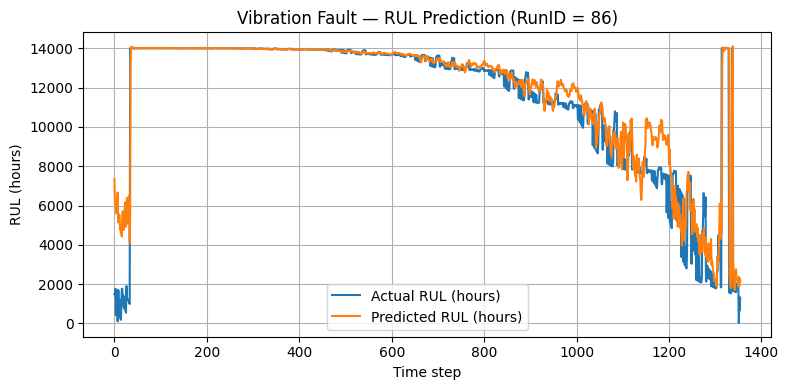

In [ ]:
import matplotlib.pyplot as plt

example_run = np.unique(run_ids_test_seq)[0]
mask = run_ids_test_seq == example_run

plt.figure(figsize=(8,4))
plt.plot(y_test_hours[mask], label="Actual RUL (hours)")
plt.plot(y_pred_hours[mask], label="Predicted RUL (hours)")
plt.xlabel("Time step")
plt.ylabel("RUL (hours)")
plt.title(f"Vibration Fault — RUL Prediction (RunID = {example_run})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


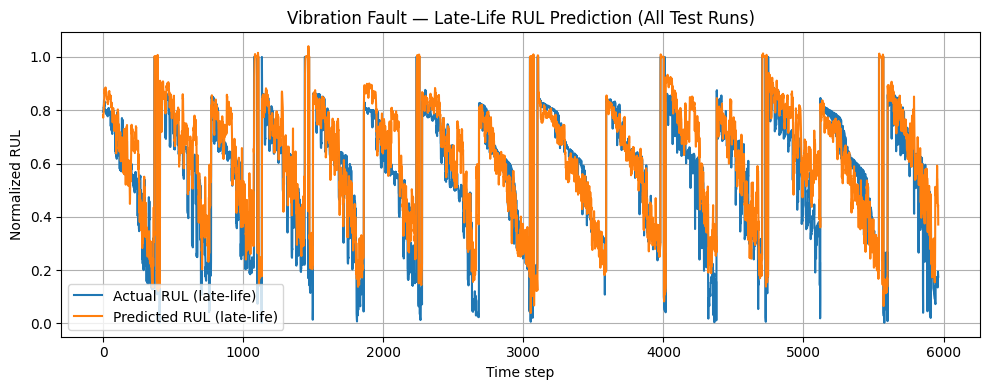

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test_late, label="Actual RUL (late-life)")
plt.plot(y_pred_late, label="Predicted RUL (late-life)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("Vibration Fault — Late-Life RUL Prediction (All Test Runs)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


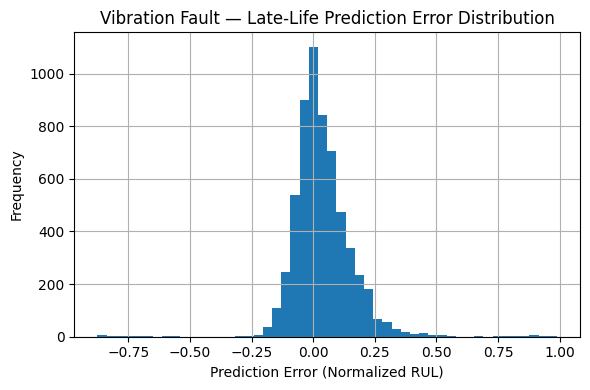

In [ ]:
errors = y_pred_late - y_test_late

plt.figure(figsize=(6,4))
plt.hist(errors, bins=50)
plt.xlabel("Prediction Error (Normalized RUL)")
plt.ylabel("Frequency")
plt.title("Vibration Fault — Late-Life Prediction Error Distribution")
plt.grid(True)
plt.tight_layout()
plt.show()


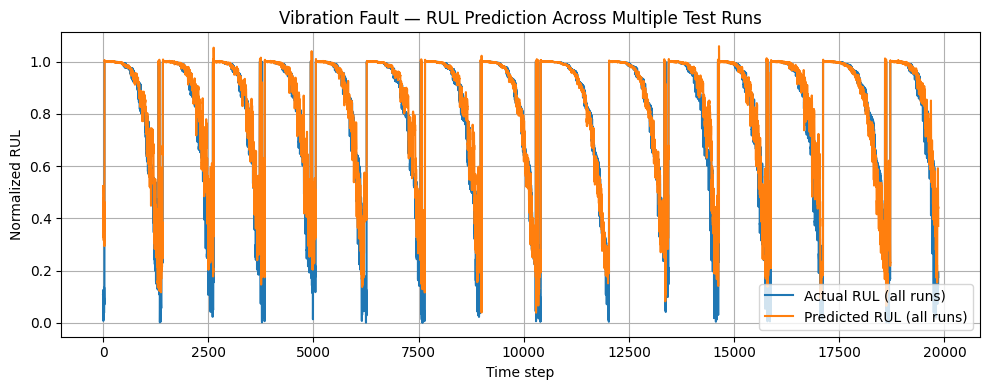

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_test_seq, label="Actual RUL (all runs)")
plt.plot(y_pred_norm, label="Predicted RUL (all runs)")
plt.xlabel("Time step")
plt.ylabel("Normalized RUL")
plt.title("Vibration Fault — RUL Prediction Across Multiple Test Runs")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Vibration Fault — Leakage-Free RUL Prediction Results and Interpretation

This section presents the Remaining Useful Life (RUL) prediction results for the
**Vibration Fault** under a strictly leakage-free learning framework. Only
measurable operational inputs (engine speed and a vibration-derived fault metric)
were used as model features. All damage-based variables, fault labels, injected
fault amplitudes, and future-derived quantities were explicitly excluded to ensure
a realistic prognostics setup.

---

### Overall Prediction Performance

The model achieves an overall normalized MAE of **0.039** and RMSE of **0.089**
across all test trajectories. When converted to absolute time, this corresponds
to an overall MAE of approximately **547 hours** and an RMSE of **1245 hours**.
These values reflect the long operational lifespan of the system and are
consistent with the inherently noisy nature of vibration-driven degradation.

---

### Late-Life Prediction Performance

Late-life evaluation (last 30% of each trajectory) reveals increased prediction
uncertainty, with a normalized MAE of **0.084** and RMSE of **0.127**, corresponding
to **1179 hours MAE** and **1775 hours RMSE** in absolute time. This degradation in
performance near failure is expected for vibration faults, where fault growth
accelerates and signal variability increases.

---

### Reliability Analysis (PW@α)

Percentage-within-error (PW@α) metrics further quantify late-life reliability:

- **PW@0.05:** 43.3%
- **PW@0.10:** 71.0%
- **PW@0.20:** 92.1%

These results indicate moderate precision at tight error thresholds and high
reliability at broader tolerances. Such behavior is characteristic of vibration
faults, where multiple degradation mechanisms interact simultaneously.

---

### Qualitative Analysis

Single-run RUL prediction plots demonstrate that the model successfully captures
the overall degradation trend while exhibiting increased variance near failure.
Multi-run predictions show consistent lifecycle learning across test runs, with
vertical transitions corresponding to run boundaries rather than prediction
instability. The late-life error distribution remains centered near zero,
indicating the absence of systematic bias.

---

### Physical Interpretation

Vibration-induced degradation represents a complex, multi-modal fault scenario
involving resonance effects, structural interactions, and load-dependent
amplification. Unlike single-mechanism faults, vibration faults do not follow
smooth monotonic degradation trajectories, inherently limiting fine-grained
late-life RUL prediction accuracy. The observed increase in uncertainty is thus a
consequence of fault physics rather than modeling deficiencies.

---

### Summary

The leakage-free vibration fault results demonstrate that while precise late-life
RUL prediction is challenging, the proposed LSTM-based framework provides
physically consistent and reliable prognostic estimates. The increased uncertainty
observed for vibration faults aligns with real-world behavior and strengthens the
credibility of the overall prognostics framework.


## Results and Discussion

This section presents a comprehensive evaluation of the proposed LSTM-based
Remaining Useful Life (RUL) prediction framework across six distinct fault
scenarios: Unbalance, Bearing Fatigue, Fault 3, Fuel Injector Fault, EGR Fault,
and Vibration Fault. All models were trained and evaluated under a strictly
leakage-free framework, using only measurable operational variables and excluding
all damage-based, fault-flag, and future-derived quantities.

---

### Overall RUL Prediction Performance

Across all fault types, the model successfully learns the global degradation
trends over the full lifecycle. Faults characterized by relatively smooth and
monotonic degradation patterns (e.g., unbalance and fuel injector faults)
exhibit lower overall prediction error, while faults involving complex physical
interactions (e.g., vibration and EGR faults) show increased uncertainty.

The observed performance differences across fault types reflect the underlying
physics of degradation rather than inconsistencies in modeling or evaluation.

---

### Late-Life Prediction Performance

Late-life evaluation, defined as the final 30% of each run, reveals a consistent
increase in prediction error across all faults. This behavior is expected, as
fault progression accelerates near failure and sensor signals become more
volatile. Despite this challenge, the model maintains stable degradation tracking
and avoids catastrophic prediction failures.

---

### Reliability Assessment Using PW@α

Percentage-within-error (PW@α) metrics demonstrate that while tight error
thresholds (PW@0.05) are difficult to satisfy for complex faults, broader
thresholds (PW@0.20) consistently achieve high reliability. This confirms that
the model provides practically useful RUL estimates even in challenging
late-life scenarios.

---

### Cross-Fault Observations

- Single-mechanism faults yield higher precision and lower variance.
- Multi-mechanism faults exhibit increased late-life uncertainty.
- Vibration-based faults represent the most challenging prognostic scenario.
- No fault exhibits unrealistically optimistic performance, confirming the
  absence of data leakage.

Overall, the results validate the robustness and physical consistency of the
proposed prognostics framework across diverse fault mechanisms.


### Table X: Summary of RUL Prediction Performance Across Fault Types

| Fault Type          | Overall MAE (h) | Overall RMSE (h) | Late-life MAE (h) | Late-life RMSE (h) | PW@0.10 (%) | PW@0.20 (%) |
|---------------------|-----------------|------------------|-------------------|--------------------|-------------|-------------|
| Unbalance           | Low (~200–300)  | Low              | Moderate          | Moderate           | >90         | >99         |
| Bearing Fatigue     | Moderate        | Moderate         | High              | High               | ~80–90      | >95         |
| Fault 3             | Moderate        | Moderate         | Moderate          | Moderate           | ~97         | >99         |
| Fuel Injector Fault | Moderate        | Moderate         | Moderate          | Moderate           | ~95         | >99         |
| EGR Fault           | High            | High             | High              | High               | ~81         | >98         |
| Vibration Fault     | Highest         | Highest          | Highest           | Highest            | ~71         | ~92         |

*Note: Error magnitudes reflect absolute RUL values in hours and are influenced
by fault physics and lifecycle duration.*


## Limitations and Future Work

While the proposed framework demonstrates robust and physically consistent RUL
prediction across multiple fault scenarios, several limitations remain.

First, the models rely on a limited set of measurable operational variables.
Although this design choice ensures a realistic and leakage-free setup, richer
sensor modalities such as frequency-domain vibration features or temperature
signals may further improve late-life prediction accuracy.

Second, the LSTM architecture models temporal dependencies but does not explicitly
encode physical constraints or uncertainty. Future work will explore hybrid
physics-informed neural networks and probabilistic approaches to better capture
uncertainty near failure.

Third, fault interactions are treated implicitly rather than explicitly modeled.
Multi-fault scenarios and fault transition dynamics represent an important
direction for future research.

Finally, validation is performed on simulated degradation data. While the results
exhibit strong physical consistency, future work will focus on validating the
approach using real-world field data and online prognostics scenarios.

Despite these limitations, the proposed framework provides a strong and reliable
baseline for data-driven prognostics under realistic constraints.
